<a href="https://colab.research.google.com/github/facuirib/Coder/blob/main/ProyectoDSParteI%2BBOSCH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import Librerias#

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Carga DataFrame#

In [ ]:
url = 'https://raw.githubusercontent.com/facuirib/Coder/refs/heads/main/bike_sales.csv'
df_sales = pd.read_csv(url)
print(df_sales.head())
#Lectura Data Frame#

         Date  Day     Month  Year  Customer_Age       Age_Group  \
0  2013-11-26   26  November  2013            19     Youth (<25)   
1  2015-11-26   26  November  2015            19     Youth (<25)   
2  2014-03-23   23     March  2014            49  Adults (35-64)   
3  2016-03-23   23     March  2016            49  Adults (35-64)   
4  2014-05-15   15       May  2014            47  Adults (35-64)   

  Customer_Gender    Country             State Product_Category Sub_Category  \
0               M     Canada  British Columbia      Accessories   Bike Racks   
1               M     Canada  British Columbia      Accessories   Bike Racks   
2               M  Australia   New South Wales      Accessories   Bike Racks   
3               M  Australia   New South Wales      Accessories   Bike Racks   
4               F  Australia   New South Wales      Accessories   Bike Racks   

               Product  Order_Quantity  Unit_Cost  Unit_Price  Profit  Cost  \
0  Hitch Rack - 4-Bike         

#Análisis DataFrame#

In [ ]:
df_sales.shape
#Info del DataFrame#

(113036, 18)

In [ ]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Date              113036 non-null  datetime64[ns]
 1   Day               113036 non-null  int64         
 2   Month             113036 non-null  object        
 3   Year              113036 non-null  int64         
 4   Customer_Age      113036 non-null  int64         
 5   Age_Group         113036 non-null  object        
 6   Customer_Gender   113036 non-null  object        
 7   Country           113036 non-null  object        
 8   State             113036 non-null  object        
 9   Product_Category  113036 non-null  object        
 10  Sub_Category      113036 non-null  object        
 11  Product           113036 non-null  object        
 12  Order_Quantity    113036 non-null  int64         
 13  Unit_Cost         113036 non-null  int64         
 14  Unit

In [ ]:
df_sales.describe()

,Day,Year,Customer_Age,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
count,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000
mean,15.665753,2014.401739,35.919212,11.901660,267.296366,452.938427,285.051665,469.318695,754.370360
std,8.781567,1.272510,11.021936,9.561857,549.835483,922.071219,453.887443,884.866118,1309.094674
min,1.000000,2011.000000,17.000000,1.000000,1.000000,2.000000,-30.000000,1.000000,2.000000
25%,8.000000,2013.000000,28.000000,2.000000,2.000000,5.000000,29.000000,28.000000,63.000000
50%,16.000000,2014.000000,35.000000,10.000000,9.000000,24.000000,101.000000,108.000000,223.000000
75%,23.000000,2016.000000,43.000000,20.000000,42.000000,70.000000,358.000000,432.000000,800.000000
max,31.000000,2016.000000,87.000000,32.000000,2171.000000,3578.000000,15096.000000,42978.000000,58074.000000


#Análisis Valores Nulos#

In [ ]:
#Sumar Valores Nulos#
df_sales.isna().sum()

,0
Date,0
Day,0
Month,0
Year,0
Customer_Age,0
Age_Group,0
Customer_Gender,0
Country,0
State,0
Product_Category,0


#Calculos Auxiliares#

In [ ]:
#Calculo Margen y Formato Fecha#
df_sales['margin']=df_sales['Profit']*df_sales['Revenue']
df_sales['Date'] = pd.to_datetime(df_sales['Date'])


# Hipótesis #

### Hipótesis 1

¿Qué país genera los mayores ingresos totales? ¿Y beneficios?


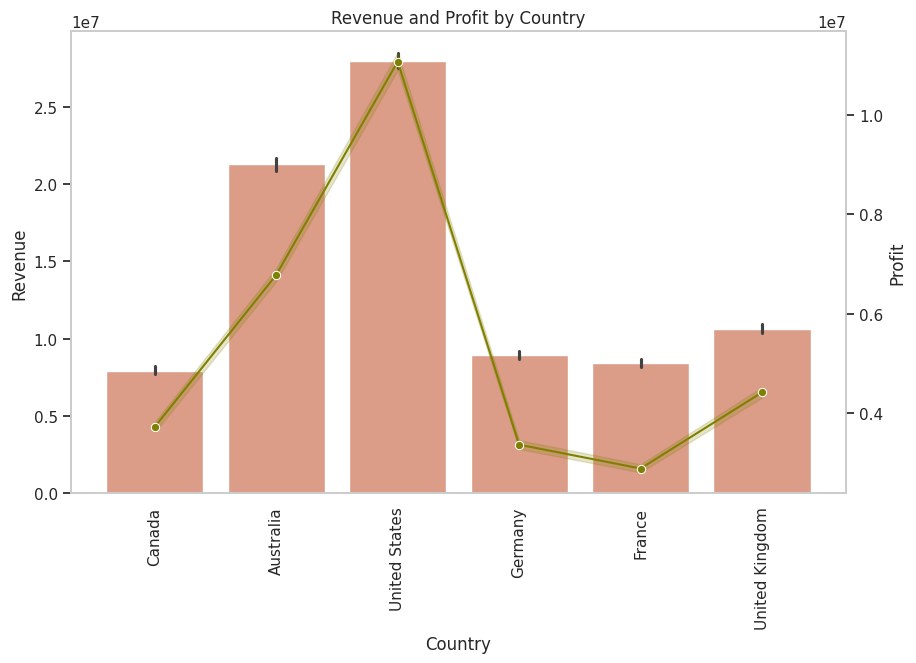

In [ ]:
sns.set_theme(style="whitegrid")
sns.set_palette("deep")
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barra de Revenue
sns.barplot(x='Country', y='Revenue', data=df_sales, estimator=sum, ax=ax1, color='darksalmon')
ax1.set_xlabel('Country')
ax1.set_ylabel('Revenue')
ax1.tick_params(axis='y')
plt.xticks(rotation=90)

# Línea de Profit (segundo eje y)
ax2 = ax1.twinx()  # Crea un segundo eje que comparte el eje x
sns.lineplot(x='Country', y='Profit', data=df_sales, estimator=sum, ax=ax2, color='olive',marker='o')
ax2.set_ylabel('Profit')
ax2.tick_params(axis='y')
ax1.grid(False)
ax2.grid(False)
plt.title('Revenue and Profit by Country')
plt.show()


### Hipótesis 2

¿Como es la distribución de nuestra clientela?


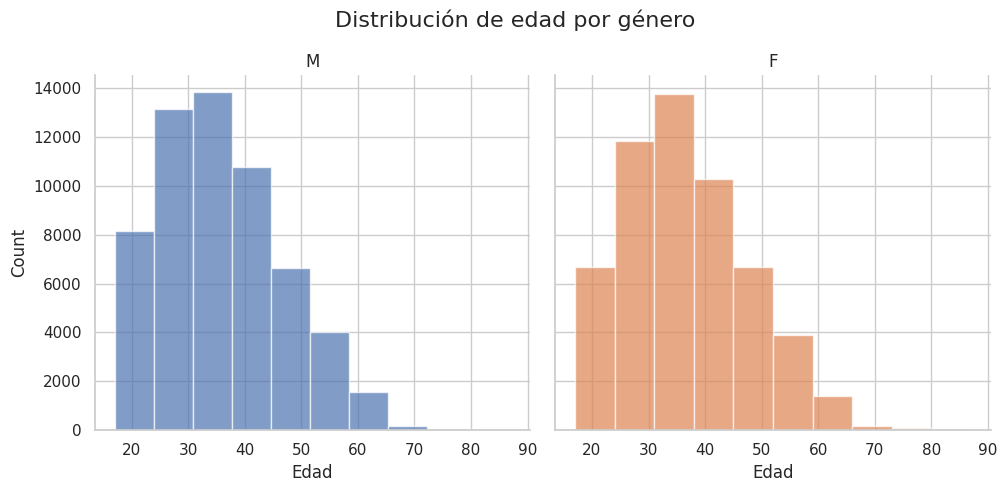

In [ ]:
g = sns.FacetGrid(df_sales, col="Customer_Gender", hue='Customer_Gender', palette="deep", height=5)
palette = {"F": "pink", "M": "darkblue"}
g.map(plt.hist, "Customer_Age", bins=10,alpha=0.7)
g.fig.suptitle("Distribución de edad por género de Clientes", fontsize=16)
g.set_axis_labels("Edad", "Count")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.85)
plt.show()

## Hipótesis 3

¿Como es la evolución de la venta año tras año por país?


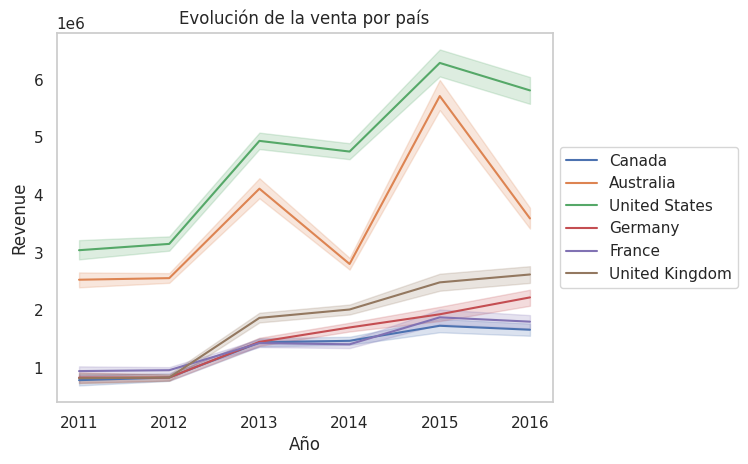

In [ ]:
sns.lineplot(x='Year', y='Revenue', hue='Country', estimator=sum, data=df_sales)
plt.title('Evolución de la venta por país')
plt.xlabel('Año')
plt.ylabel('Revenue')
plt.legend(title='País')
plt.grid(False)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

## Hipótesis 4 ##

¿Como es la distribución del ticket promedio por país?


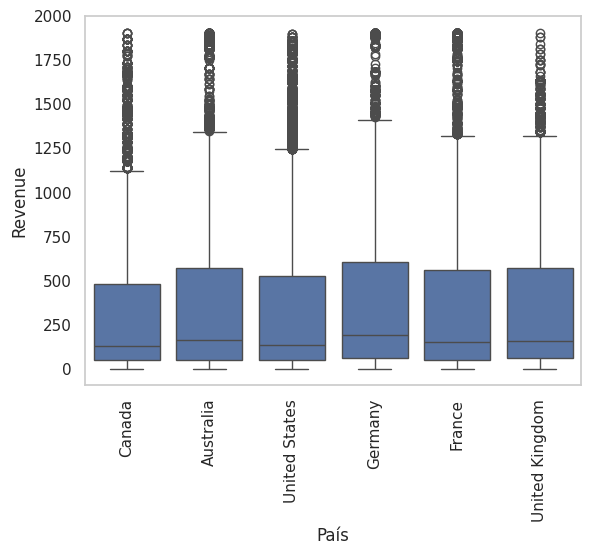

In [ ]:
import matplotlib.cbook as cbook
outliers = cbook.boxplot_stats(df_sales['Revenue'])[0]['fliers']
df_sales_filtered = df_sales[~df_sales['Revenue'].isin(outliers)]

sns.boxplot(x='Country', y='Revenue', data=df_sales_filtered)
plt.xlabel('País')
plt.ylabel('Revenue')
plt.xticks(rotation=90)
plt.grid(False)
plt.show()